In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from tqdm import tqdm
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import sys
import warnings
warnings.filterwarnings("ignore")

# to visualise al the columns in the dataframe
pd.pandas.set_option('display.max_columns', None)


Xử lý dữ liệu bảng :"application_train"

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/home-credit-default-risk/application_train.csv")
data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [ ]:
data.describe()

In [ ]:
data.columns.values

In [ ]:
data.shape

In [ ]:
data.dtypes.value_counts()

In [ ]:
# Number of unique classes in each object column
# -- of catagorical variable
data.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

In [ ]:
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()

        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)

        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})

        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)

        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")


        # Return the dataframe with missing information
        return mis_val_table_ren_columns

In [ ]:
missing_values_table(data).head(20)

In [ ]:
data["TARGET"].value_counts()
(data["TARGET"].value_counts()/data["TARGET"].count())*100

,count
TARGET,
0,91.927118
1,8.072882


In [ ]:
data.columns

Những cột quan trọng, có khả năng ảnh hưởng lớn đến khả năng trả nợ:

- NAME_CONTRACT_TYPE: Loại hợp đồng vay (tín chấp hay thế chấp) có
thể ảnh hưởng đến mức độ rủi ro tín dụng.
- CODE_GENDER: Giới tính có thể ảnh hưởng đến thói quen chi tiêu và vay nợ.
- FLAG_OWN_CAR: Việc sở hữu xe có thể chỉ ra khả năng tài chính của khách hàng.
- FLAG_OWN_REALTY: Việc sở hữu bất động sản cũng là một yếu tố phản ánh năng lực tài chính.
- CNT_CHILDREN: Số con có thể ảnh hưởng đến khả năng trả nợ do tăng gánh nặng tài chính.
- AMT_INCOME_TOTAL: Tổng thu nhập là một chỉ số rất quan trọng để đánh giá khả năng trả nợ.
- AMT_CREDIT: Số tiền vay sẽ ảnh hưởng đến khả năng trả nợ của khách hàng.
- AMT_ANNUITY: Số tiền trả hàng năm liên quan đến khoản vay, có tác động trực tiếp đến khả năng trả nợ.
- AMT_GOODS_PRICE: Giá trị của tài sản/vật phẩm được mua bằng khoản vay, có thể liên quan đến mức độ rủi ro.
- NAME_INCOME_TYPE: Loại thu nhập (lương, kinh doanh, trợ cấp) có thể ảnh hưởng đến độ ổn định của thu nhập.
- NAME_EDUCATION_TYPE: Trình độ học vấn có thể phản ánh năng lực thu nhập.
- NAME_FAMILY_STATUS: Tình trạng hôn nhân có thể ảnh hưởng đến chi tiêu và khả năng trả nợ.
- NAME_HOUSING_TYPE: Loại nhà ở (thuê, sở hữu) cũng phản ánh tình hình tài chính.
- REGION_POPULATION_RELATIVE: Mật độ dân cư có thể chỉ ra môi trường sống và mức sống của khách hàng.
- DAYS_BIRTH: Tuổi của khách hàng, có liên quan đến mức độ rủi ro tín dụng.
- DAYS_EMPLOYED: Thời gian làm việc của khách hàng, phản ánh độ ổn định nghề nghiệp.
- EXT_SOURCE_2, EXT_SOURCE_3: Đây là các nguồn dữ liệu bên ngoài về khách hàng, có khả năng rất cao ảnh hưởng đến dự đoán.

Những cột có liên quan nhưng mức ảnh hưởng có thể không mạnh:

- DAYS_REGISTRATION: Thời gian khách hàng đăng ký tài sản có thể liên quan đến việc đánh giá rủi ro nhưng không phải là yếu tố chính.
- DAYS_ID_PUBLISH: Ngày cập nhật thông tin ID của khách hàng.
- FLAG_WORK_PHONE, FLAG_PHONE, FLAG_EMAIL: Sự có mặt của các liên hệ này có thể không ảnh hưởng lớn đến khả năng trả nợ nhưng thể hiện tính hợp pháp và độ tin cậy của khách hàng.
- OCCUPATION_TYPE: Nghề nghiệp có thể phản ánh năng lực tài chính, nhưng không phải lúc nào cũng là yếu tố quyết định.
- CNT_FAM_MEMBERS: Số thành viên trong gia đình, tương tự như số con, ảnh hưởng đến gánh nặng tài chính.
- REGION_RATING_CLIENT, REGION_RATING_CLIENT_W_CITY: Đánh giá khu vực có thể liên quan đến mức sống và khả năng chi trả.

Những cột có thể bỏ đi hoặc ít ảnh hưởng trực tiếp đến dự đoán:

- FLAG_MOBIL: Việc có điện thoại di động không ảnh hưởng trực tiếp đến khả năng trả nợ.
- FLAG_CONT_MOBILE: Tương tự như trên, thông tin về tính liên tục của số điện thoại không quan trọng trong việc dự đoán khả năng tài chính.
- REG_REGION_NOT_LIVE_REGION, REG_REGION_NOT_WORK_REGION, LIVE_REGION_NOT_WORK_REGION, REG_CITY_NOT_LIVE_CITY, REG_CITY_NOT_WORK_CITY, LIVE_CITY_NOT_WORK_CITY: Những cột này chỉ phản ánh sự khác biệt giữa nơi làm việc và nơi sinh sống, có thể không ảnh hưởng nhiều đến khả năng trả nợ.
- WEEKDAY_APPR_PROCESS_START, HOUR_APPR_PROCESS_START: Thời gian bắt đầu xử lý đơn vay không ảnh hưởng trực tiếp đến khả năng tài chính.
- FLAG_DOCUMENT_2 đến FLAG_DOCUMENT_21: Các cột này chỉ thể hiện việc nộp các loại giấy tờ, có thể bỏ qua nếu không cần thiết.
- OBS_30_CNT_SOCIAL_CIRCLE, DEF_30_CNT_SOCIAL_CIRCLE, OBS_60_CNT_SOCIAL_CIRCLE, DEF_60_CNT_SOCIAL_CIRCLE: Các cột này phản ánh số lượng quan hệ xã hội của khách hàng, ít ảnh hưởng đến khả năng trả nợ.
- AMT_REQ_CREDIT_BUREAU_HOUR, AMT_REQ_CREDIT_BUREAU_DAY, AMT_REQ_CREDIT_BUREAU_WEEK, AMT_REQ_CREDIT_BUREAU_MON, AMT_REQ_CREDIT_BUREAU_QRT, AMT_REQ_CREDIT_BUREAU_YEAR: Số lần kiểm tra tín dụng theo thời gian có thể có ảnh hưởng nhất định, nhưng mức độ tác động thấp so với các biến tài chính.

Xóa các cột không sử dụng hoặc ít ảnh hưởng. sau đó điền các dữ liệu còn trống


In [ ]:
columns_drop = ['FLAG_MOBIL',
    'FLAG_CONT_MOBILE',
    'REG_REGION_NOT_LIVE_REGION',
    'REG_REGION_NOT_WORK_REGION',
    'LIVE_REGION_NOT_WORK_REGION',
    'REG_CITY_NOT_LIVE_CITY',
    'REG_CITY_NOT_WORK_CITY',
    'LIVE_CITY_NOT_WORK_CITY',
    'WEEKDAY_APPR_PROCESS_START',
    'HOUR_APPR_PROCESS_START',
    'FLAG_DOCUMENT_2',
    'FLAG_DOCUMENT_3',
    'FLAG_DOCUMENT_4',
    'FLAG_DOCUMENT_5',
    'FLAG_DOCUMENT_6',
    'FLAG_DOCUMENT_7',
    'FLAG_DOCUMENT_8',
    'FLAG_DOCUMENT_9',
    'FLAG_DOCUMENT_10',
    'FLAG_DOCUMENT_11',
    'FLAG_DOCUMENT_12',
    'FLAG_DOCUMENT_13',
    'FLAG_DOCUMENT_14',
    'FLAG_DOCUMENT_15',
    'FLAG_DOCUMENT_16',
    'FLAG_DOCUMENT_17',
    'FLAG_DOCUMENT_18',
    'FLAG_DOCUMENT_19',
    'FLAG_DOCUMENT_20',
    'FLAG_DOCUMENT_21',
    'OBS_30_CNT_SOCIAL_CIRCLE',
    'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE',
    'DEF_60_CNT_SOCIAL_CIRCLE',
    'AMT_REQ_CREDIT_BUREAU_HOUR',
    'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_YEAR']
data = data.drop(columns_drop, axis=1)
data

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,DAYS_LAST_PHONE_CHANGE
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,0,1,0,Laborers,1.0,2,2,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,-1134.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,0,1,0,Core staff,2.0,1,1,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,-828.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,0,Laborers,1.0,2,2,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-815.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,0,0,0,Laborers,2.0,2,2,Business Entity Type 3,NaN,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-617.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,0,0,0,Core staff,1.0,2,2,Religion,NaN,0.322738,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1106.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [ ]:
data.columns.values

In [ ]:
missing_values_table(data)

Your selected dataframe has 82 columns.
There are 57 columns that have missing values.


,Missing Values,% of Total Values
COMMONAREA_AVG,214865,69.9
COMMONAREA_MEDI,214865,69.9
COMMONAREA_MODE,214865,69.9
NONLIVINGAPARTMENTS_AVG,213514,69.4
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_MODE,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_AVG,210199,68.4
LIVINGAPARTMENTS_MODE,210199,68.4


In [ ]:
# Tính toán các giá trị median cho các cột số
median_amt_annuity = data["AMT_ANNUITY"].median()
median_amt_goods_price = data["AMT_GOODS_PRICE"].median()
median_cnt_fam_members = data["CNT_FAM_MEMBERS"].median()
median_ext_source_2 = data["EXT_SOURCE_2"].median()
median_ext_source_3 = data["EXT_SOURCE_3"].median()
median_days_last_phone_change = data["DAYS_LAST_PHONE_CHANGE"].median()

# Điền missing values bằng median
data = data.fillna({
    'AMT_ANNUITY': median_amt_annuity,
    'AMT_GOODS_PRICE': median_amt_goods_price,
    'CNT_FAM_MEMBERS': median_cnt_fam_members,
    'EXT_SOURCE_2': median_ext_source_2,
    'EXT_SOURCE_3': median_ext_source_3,
    'DAYS_LAST_PHONE_CHANGE': median_days_last_phone_change
})

# Tính toán mode cho NAME_TYPE_SUITE
mode_name_type_suite = data["NAME_TYPE_SUITE"].mode()[0]

# Điền missing values cho cột phân loại
data = data.fillna({
    'NAME_TYPE_SUITE': mode_name_type_suite,
    'OCCUPATION_TYPE': 'Unknown'
})

In [ ]:
missing_values_table(data)
data

Your selected dataframe has 82 columns.
There are 49 columns that have missing values.


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,DAYS_LAST_PHONE_CHANGE
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,0,1,0,Laborers,1.0,2,2,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,-1134.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,0,1,0,Core staff,2.0,1,1,School,0.311267,0.622246,0.535276,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,-828.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,0,Laborers,1.0,2,2,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-815.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,0,0,0,Laborers,2.0,2,2,Business Entity Type 3,NaN,0.650442,0.535276,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-617.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,0,0,0,Core staff,1.0,2,2,Religion,NaN,0.322738,0.535276,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1106.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [ ]:
cols_to_drop = [col for col in data.columns if "_MEDI" in col]
data = data.drop(columns=cols_to_drop)


In [ ]:
missing_values_table(data)

Your selected dataframe has 68 columns.
There are 35 columns that have missing values.


,Missing Values,% of Total Values
COMMONAREA_AVG,214865,69.9
COMMONAREA_MODE,214865,69.9
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_AVG,210199,68.4
LIVINGAPARTMENTS_MODE,210199,68.4
FLOORSMIN_MODE,208642,67.8
FLOORSMIN_AVG,208642,67.8
YEARS_BUILD_MODE,204488,66.5


In [ ]:
cols_to_drop = [col for col in data.columns if '_AVG' in col]
data = data.drop(columns=cols_to_drop)


In [ ]:
data

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,DAYS_LAST_PHONE_CHANGE
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,0,1,0,Laborers,1.0,2,2,Business Entity Type 3,0.083037,0.262949,0.139376,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,-1134.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,0,1,0,Core staff,2.0,1,1,School,0.311267,0.622246,0.535276,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0,0.0000,reg oper account,block of flats,0.0714,Block,No,-828.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,0,Laborers,1.0,2,2,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-815.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,0,0,0,Laborers,2.0,2,2,Business Entity Type 3,NaN,0.650442,0.535276,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-617.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,0,0,0,Core staff,1.0,2,2,Religion,NaN,0.322738,0.535276,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1106.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,225000.0,Unaccompanied,Working,Secondary / secondary special,Separated,With parents,0.032561,-9327,-236,-8456.0,-1982,NaN,1,0,0,0,Sales staff,1.0,1,1,Services,0.145570,0.681632,0.535276,0.1008,0.0172,0.9782,0.7125,0.0172,0.0806,0.0345,0.4583,0.0417,0.0094,0.0882,0.0853,0.0,0.0125,reg oper account,block of flats,0.2898,"Stone, brick",No,-273.0
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,225000.0,Unaccompanied,Pensioner,Secondary / secondary special,Widow,House / apartment,0.025164,-20775,365243,-4388.0,-4090,NaN,0,0,1,0,Unknown,1.0,2,2,XNA,NaN,0.115992,0.535276,0.0252,0.0451,0.9727,0.6406,0.0022,0.0000,0.1034,0.0833,0.1250,0.0592,0.0220,0.0267,0.0,0.0000,reg oper account,block of flats,0.0214,"Stone, brick",No,0.0
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,585000.0,Unaccompanied,Working,Higher education,Separated,House / apartment,0.005002,-14966,-7921,-6737.0,-5150,NaN,1,0,0,1,Managers,1.0,3,3,School,0.744026,0.535722,0.218859,0.1050,0.0894,0.9816,0.

In [ ]:
cols_to_drop = [col for col in data.columns if '_MODE' in col]
data = data.drop(columns=cols_to_drop)

In [ ]:
missing_values_table(data)

Your selected dataframe has 35 columns.
There are 2 columns that have missing values.


,Missing Values,% of Total Values
OWN_CAR_AGE,202929,66.0
EXT_SOURCE_1,173378,56.4


In [ ]:
data = data.fillna({"EXT_SOURCE_1": data["EXT_SOURCE_1"].median()})

In [ ]:
data_clean = data.copy()
data['OWN_CAR_AGE_NULL'] = data['OWN_CAR_AGE'].isna().astype(int)
data['OWN_CAR_AGE'] = data['OWN_CAR_AGE'].fillna(0)

In [ ]:
data

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,OWN_CAR_AGE_NULL
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,0.0,1,0,1,0,Laborers,1.0,2,2,Business Entity Type 3,0.083037,0.262949,0.139376,-1134.0,1
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,0.0,1,0,1,0,Core staff,2.0,1,1,School,0.311267,0.622246,0.535276,-828.0,1
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,0,Laborers,1.0,2,2,Government,0.505998,0.555912,0.729567,-815.0,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,0.0,1,0,0,0,Laborers,2.0,2,2,Business Entity Type 3,0.505998,0.650442,0.535276,-617.0,1
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,0.0,1,0,0,0,Core staff,1.0,2,2,Religion,0.505998,0.322738,0.535276,-1106.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,225000.0,Unaccompanied,Working,Secondary / secondary special,Separated,With parents,0.032561,-9327,-236,-8456.0,-1982,0.0,1,0,0,0,Sales staff,1.0,1,1,Services,0.145570,0.681632,0.535276,-273.0,1
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,225000.0,Unaccompanied,Pensioner,Secondary / secondary special,Widow,House / apartment,0.025164,-20775,365243,-4388.0,-4090,0.0,0,0,1,0,Unknown,1.0,2,2,XNA,0.505998,0.115992,0.535276,0.0,1
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,585000.0,Unaccompanied,Working,Higher education,Separated,House / apartment,0.005002,-14966,-7921,-6737.0,-5150,0.0,1,0,0,1,Managers,1.0,3,3,School,0.744026,0.535722,0.218859,-1909.0,1
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,319500.0,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,0.005313,-11961,-4786,-2562.0,-931,0.0,1,0,0,0,Laborers,2.0,2,2,Business Entity Type 1,0.505998,0.514163,0.661024,-322.0,1


In [ ]:
data = data.drop(["OWN_CAR_AGE_NULL"], axis=1)

In [ ]:
data_clean = data.copy()

In [ ]:
data_clean.to_csv("/content/drive/MyDrive/data_clean.csv", index=False)

In [ ]:
!nvidia-smi

In [ ]:
temp = data_clean["TARGET"].value_counts()
df = pd.DataFrame({'labels': temp.index,
                   'values': temp.values
                  })
plt.figure(figsize = (6,6))
plt.title('Application loans repayed dataset')
sns.set_color_codes("pastel")
sns.barplot(x = 'labels', y="values", data=df)
plt.show()

**EDA**
- Loan types
Let's see the type of the loans taken and also, on a separate plot, the percent of the loans (by type of the loan) with TARGET value 1 (not returned loan).


In [ ]:
def plot_stats(feature,label_rotation=False,horizontal_layout=True):
    temp = data[feature].value_counts()
    df1 = pd.DataFrame({feature: temp.index,'Number of contracts': temp.values})

    # Calculate the percentage of target=1 per category value
    cat_perc = data[[feature, 'TARGET']].groupby([feature],as_index=False).mean()
    cat_perc.sort_values(by='TARGET', ascending=False, inplace=True)

    if(horizontal_layout):
        fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,6))
    else:
        fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(12,14))
    sns.set_color_codes("pastel")
    s = sns.barplot(ax=ax1, x = feature, y="Number of contracts",data=df1)

    if(label_rotation):
        s.set_xticklabels(s.get_xticklabels(),rotation=90)

    s = sns.barplot(ax=ax2, x = feature, y='TARGET', order=cat_perc[feature], data=cat_perc)

    if(label_rotation):
        s.set_xticklabels(s.get_xticklabels(),rotation=90)
    plt.ylabel('Percent of target with value 1 [%]', fontsize=10)
    plt.tick_params(axis='both', which='major', labelsize=10)

    plt.show();
plot_stats('NAME_CONTRACT_TYPE')

In [ ]:
plot_stats("CODE_GENDER")

Số lượng khách hàng nữ gần gấp đôi số lượng khách hàng nam. Xét về tỷ lệ tín dụng vỡ nợ, nam giới có nguy cơ không trả được nợ cao hơn.

In [ ]:
data_clean.dtypes == "object"

In [ ]:
data_clean

Sử dụng One-Hot Encoding:

- NAME_CONTRACT_TYPE: Loại hợp đồng (có ít giá trị phân loại: Cash, Revolving, Consumer).
- CODE_GENDER: Giới tính (Male, Female).
- FLAG_OWN_CAR: Có xe hay không (Yes/No).
- FLAG_OWN_REALTY: Có bất động sản hay không (Yes/No).
- NAME_TYPE_SUITE: Người đi cùng khi nộp đơn vay (nhiều giá trị nhưng thường là các lựa chọn riêng biệt không có thứ tự rõ ràng).
- NAME_FAMILY_STATUS: Tình trạng hôn nhân (Married, Single, Separated,...).
- NAME_HOUSING_TYPE: Loại hình nhà ở (House, Apartment, Co-op...).


Sử dụng Label Encoding:

- NAME_INCOME_TYPE: Loại thu nhập (lương, kinh doanh, hưu trí... có nhiều giá trị, nhưng không cần mã hóa OHE do các mô hình cây xử lý tốt với Label Encoding).
- NAME_EDUCATION_TYPE: Trình độ học vấn (Secondary, Higher, Academic... có tính thứ tự).
- OCCUPATION_TYPE: Loại nghề nghiệp (nhiều giá trị phân loại, Label Encoding hợp lý hơn vì nghề nghiệp có thể có ảnh hưởng đặc biệt và nhiều giá trị).
- ORGANIZATION_TYPE: Loại hình tổ chức (công ty, trường học, bệnh viện... có nhiều giá trị, Label Encoding là giải pháp tốt hơn).

In [ ]:
berau = pd.read_csv("/content/drive/MyDrive/home-credit-default-risk/bureau.csv")
previous = pd.read_csv("/content/drive/MyDrive/home-credit-default-risk/previous_application.csv")

berau

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.00,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.00,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.50,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.00,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.00,NaN,NaN,0.0,Consumer credit,-21,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,259355,5057750,Active,currency 1,-44,0,-30.0,NaN,0.0,0,11250.00,11250.0,0.0,0.0,Microloan,-19,NaN
1716424,100044,5057754,Closed,currency 1,-2648,0,-2433.0,-2493.0,5476.5,0,38130.84,0.0,0.0,0.0,Consumer credit,-2493,NaN
1716425,100044,5057762,Closed,currency 1,-1809,0,-1628.0,-970.0,NaN,0,15570.00,NaN,NaN,0.0,Consumer credit,-967,NaN
1716426,246829,5057770,Closed,currency 1,-1878,0,-1513.0,-1513.0,NaN,0,36000.00,0.0,0.0,0.0,Consumer credit,-1508,NaN


In [ ]:
df_filtered = berau[berau['SK_ID_CURR'] == 215354]

print("--- Các hàng có SK_ID_CURR là 215354 ---")
print(df_filtered)


--- Các hàng có SK_ID_CURR là 215354 ---
        SK_ID_CURR  SK_ID_BUREAU CREDIT_ACTIVE CREDIT_CURRENCY  DAYS_CREDIT  \
0           215354       5714462        Closed      currency 1         -497   
1           215354       5714463        Active      currency 1         -208   
2           215354       5714464        Active      currency 1         -203   
3           215354       5714465        Active      currency 1         -203   
4           215354       5714466        Active      currency 1         -629   
5           215354       5714467        Active      currency 1         -273   
6           215354       5714468        Active      currency 1          -43   
225157      215354       5714458        Closed      currency 1        -1872   
225158      215354       5714459        Closed      currency 1        -1734   
225159      215354       5714460        Closed      currency 1        -1333   
225160      215354       5714461        Closed      currency 1        -1011   

        CR

In [ ]:
berau["AMT_ANNUITY"].value_counts()

,count
AMT_ANNUITY,
0.000,256915
4500.000,5182
13500.000,3147
22500.000,2502
9000.000,1725
...,...
4161.195,1
97609.500,1
3584.250,1


In [ ]:
Sk_id = berau.groupby(["SK_ID_CURR"])

In [ ]:
Sk_id["CREDIT_ACTIVE"].value_counts()

SK_ID_CURR  CREDIT_ACTIVE
100001      Closed           4
            Active           3
100002      Closed           6
            Active           2
100003      Closed           3
                            ..
456253      Active           2
            Closed           2
456254      Closed           1
456255      Closed           6
            Active           5
Name: count, Length: 525782, dtype: int64

In [ ]:
missing_values_table(berau).head(20)

Your selected dataframe has 17 columns.
There are 7 columns that have missing values.


,Missing Values,% of Total Values
AMT_ANNUITY,1226791,71.5
AMT_CREDIT_MAX_OVERDUE,1124488,65.5
DAYS_ENDDATE_FACT,633653,36.9
AMT_CREDIT_SUM_LIMIT,591780,34.5
AMT_CREDIT_SUM_DEBT,257669,15.0
DAYS_CREDIT_ENDDATE,105553,6.1
AMT_CREDIT_SUM,13,0.0


In [ ]:
num_agg = {
    'DAYS_CREDIT': ['min', 'max', 'mean', 'median'],
    'CREDIT_DAY_OVERDUE': ['max', 'mean'],
    'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
    'AMT_CREDIT_SUM': ['sum', 'max', 'mean'],
    'AMT_CREDIT_SUM_DEBT': ['sum', 'max', 'mean'],
    'AMT_CREDIT_SUM_OVERDUE': ['sum', 'mean'],
    'AMT_ANNUITY': ['mean'],
    'CNT_CREDIT_PROLONG': ['sum', 'mean']
}
#2. Aggregate numeric toàn bộ bureau
berau_num_agg = berau.groupby('SK_ID_CURR').agg(num_agg)
berau_num_agg.columns = [f'BUREAU_{col[0]}_{col[1].upper()}' for col in berau_num_agg.columns]

In [ ]:
#3. Aggregate categorical
berau_cat = pd.get_dummies(berau[['SK_ID_CURR', 'CREDIT_ACTIVE', 'CREDIT_TYPE']],
                            drop_first=False)

berau_cat_agg = berau_cat.groupby('SK_ID_CURR').sum()
berau_cat_agg.columns = [f'BUREAU_{c}' for c in berau_cat_agg.columns]


In [ ]:
# 4. Tạo đặc trưng số lượng khoản vay
# ===========================
berau_count = berau.groupby('SK_ID_CURR').size().rename('BUREAU_COUNT')

# 5. Gộp tất cả bureau features
berau_features = (
    berau_num_agg
    .join(berau_cat_agg, how='left')
    .join(berau_count, how='left')
)

berau_features.head()

,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MEDIAN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_DAYS_CREDIT_ENDDATE_MIN,BUREAU_DAYS_CREDIT_ENDDATE_MAX,BUREAU_DAYS_CREDIT_ENDDATE_MEAN,BUREAU_AMT_CREDIT_SUM_SUM,BUREAU_AMT_CREDIT_SUM_MAX,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_AMT_CREDIT_SUM_DEBT_MAX,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM,BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN,BUREAU_AMT_ANNUITY_MEAN,BUREAU_CNT_CREDIT_PROLONG_SUM,BUREAU_CNT_CREDIT_PROLONG_MEAN,BUREAU_CREDIT_ACTIVE_Active,BUREAU_CREDIT_ACTIVE_Bad debt,BUREAU_CREDIT_ACTIVE_Closed,BUREAU_CREDIT_ACTIVE_Sold,BUREAU_CREDIT_TYPE_Another type of loan,BUREAU_CREDIT_TYPE_Car loan,BUREAU_CREDIT_TYPE_Cash loan (non-earmarked),BUREAU_CREDIT_TYPE_Consumer credit,BUREAU_CREDIT_TYPE_Credit card,BUREAU_CREDIT_TYPE_Interbank credit,BUREAU_CREDIT_TYPE_Loan for business development,BUREAU_CREDIT_TYPE_Loan for purchase of shares (margin lending),BUREAU_CREDIT_TYPE_Loan for the purchase of equipment,BUREAU_CREDIT_TYPE_Loan for working capital replenishment,BUREAU_CREDIT_TYPE_Microloan,BUREAU_CREDIT_TYPE_Mobile operator loan,BUREAU_CREDIT_TYPE_Mortgage,BUREAU_CREDIT_TYPE_Real estate loan,BUREAU_CREDIT_TYPE_Unknown type of loan,BUREAU_COUNT
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
100001,-1572,-49,-735.000000,-857.0,0,0.0,-1329.0,1778.0,82.428571,1453365.000,378000.0,207623.571429,596686.5,373239.0,85240.928571,0.0,0.0,3545.357143,0,0.0,3,0,4,0,0,0,0,7,0,0,0,0,0,0,0,0,0,0,0,7
100002,-1437,-103,-874.000000,-1042.5,0,0.0,-1072.0,780.0,-349.000000,865055.565,450000.0,108131.945625,245781.0,245781.0,49156.200000,0.0,0.0,0.000000,0,0.0,2,0,6,0,0,0,0,4,4,0,0,0,0,0,0,0,0,0,0,8
100003,-2586,-606,-1400.750000,-1205.5,0,0.0,-2434.0,1216.0,-544.500000,1017400.500,810000.0,254350.125000,0.0,0.0,0.000000,0.0,0.0,NaN,0,0.0,1,0,3,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,4
100004,-1326,-408,-867.000000,-867.0,0,0.0,-595.0,-382.0,-488.500000,189037.800,94537.8,94518.900000,0.0,0.0,0.000000,0.0,0.0,NaN,0,0.0,0,0,2,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,2
100005,-373,-62,-190.666667,-137.0,0,0.0,-128.0,1324.0,439.333333,657126.000,568800.0,219042.000000,568408.5,543087.0,189469.500000,0.0,0.0,1420.500000,0,0.0,2,0,1,0,0,0,0,2,1,0,0,0,0,0,0,0,0,0,0,3


In [ ]:
berau_features.columns

Index(['BUREAU_DAYS_CREDIT_MIN', 'BUREAU_DAYS_CREDIT_MAX',
       'BUREAU_DAYS_CREDIT_MEAN', 'BUREAU_DAYS_CREDIT_MEDIAN',
       'BUREAU_CREDIT_DAY_OVERDUE_MAX', 'BUREAU_CREDIT_DAY_OVERDUE_MEAN',
       'BUREAU_DAYS_CREDIT_ENDDATE_MIN', 'BUREAU_DAYS_CREDIT_ENDDATE_MAX',
       'BUREAU_DAYS_CREDIT_ENDDATE_MEAN', 'BUREAU_AMT_CREDIT_SUM_SUM',
       'BUREAU_AMT_CREDIT_SUM_MAX', 'BUREAU_AMT_CREDIT_SUM_MEAN',
       'BUREAU_AMT_CREDIT_SUM_DEBT_SUM', 'BUREAU_AMT_CREDIT_SUM_DEBT_MAX',
       'BUREAU_AMT_CREDIT_SUM_DEBT_MEAN', 'BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM',
       'BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN', 'BUREAU_AMT_ANNUITY_MEAN',
       'BUREAU_CNT_CREDIT_PROLONG_SUM', 'BUREAU_CNT_CREDIT_PROLONG_MEAN',
       'BUREAU_CREDIT_ACTIVE_Active', 'BUREAU_CREDIT_ACTIVE_Bad debt',
       'BUREAU_CREDIT_ACTIVE_Closed', 'BUREAU_CREDIT_ACTIVE_Sold',
       'BUREAU_CREDIT_TYPE_Another type of loan',
       'BUREAU_CREDIT_TYPE_Car loan',
       'BUREAU_CREDIT_TYPE_Cash loan (non-earmarked)',
       'BUR

In [ ]:
# Lọc khoản vay đang hoạt động
berau_active = berau[berau['CREDIT_ACTIVE'] == 'Active']

active_agg = berau_active.groupby('SK_ID_CURR').agg({
    'AMT_CREDIT_SUM': ['mean', 'max'],
    'AMT_CREDIT_SUM_DEBT': ['mean', 'max'],
    'DAYS_CREDIT': ['mean', 'max'],
})

active_agg.columns = [f'ACTIVE_{c[0]}_{c[1].upper()}' for c in active_agg.columns]

In [ ]:
berau_full = berau_features.join(active_agg, how='left')
berau_full

,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MEDIAN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_DAYS_CREDIT_ENDDATE_MIN,BUREAU_DAYS_CREDIT_ENDDATE_MAX,BUREAU_DAYS_CREDIT_ENDDATE_MEAN,BUREAU_AMT_CREDIT_SUM_SUM,BUREAU_AMT_CREDIT_SUM_MAX,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_AMT_CREDIT_SUM_DEBT_MAX,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM,BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN,BUREAU_AMT_ANNUITY_MEAN,BUREAU_CNT_CREDIT_PROLONG_SUM,BUREAU_CNT_CREDIT_PROLONG_MEAN,BUREAU_CREDIT_ACTIVE_Active,BUREAU_CREDIT_ACTIVE_Bad debt,BUREAU_CREDIT_ACTIVE_Closed,BUREAU_CREDIT_ACTIVE_Sold,BUREAU_CREDIT_TYPE_Another type of loan,BUREAU_CREDIT_TYPE_Car loan,BUREAU_CREDIT_TYPE_Cash loan (non-earmarked),BUREAU_CREDIT_TYPE_Consumer credit,BUREAU_CREDIT_TYPE_Credit card,BUREAU_CREDIT_TYPE_Interbank credit,BUREAU_CREDIT_TYPE_Loan for business development,BUREAU_CREDIT_TYPE_Loan for purchase of shares (margin lending),BUREAU_CREDIT_TYPE_Loan for the purchase of equipment,BUREAU_CREDIT_TYPE_Loan for working capital replenishment,BUREAU_CREDIT_TYPE_Microloan,BUREAU_CREDIT_TYPE_Mobile operator loan,BUREAU_CREDIT_TYPE_Mortgage,BUREAU_CREDIT_TYPE_Real estate loan,BUREAU_CREDIT_TYPE_Unknown type of loan,BUREAU_COUNT,ACTIVE_AMT_CREDIT_SUM_MEAN,ACTIVE_AMT_CREDIT_SUM_MAX,ACTIVE_AMT_CREDIT_SUM_DEBT_MEAN,ACTIVE_AMT_CREDIT_SUM_DEBT_MAX,ACTIVE_DAYS_CREDIT_MEAN,ACTIVE_DAYS_CREDIT_MAX
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
100001,-1572,-49,-735.000000,-857.0,0,0.0,-1329.0,1778.0,82.428571,1453365.000,378000.00,2.076236e+05,596686.500,373239.00,85240.928571,0.0,0.0,3545.357143,0,0.000000,3,0,4,0,0,0,0,7,0,0,0,0,0,0,0,0,0,0,0,7,2.946750e+05,378000.00,1.988955e+05,373239.00,-309.333333,-49.0
100002,-1437,-103,-874.000000,-1042.5,0,0.0,-1072.0,780.0,-349.000000,865055.565,450000.00,1.081319e+05,245781.000,245781.00,49156.200000,0.0,0.0,0.000000,0,0.000000,2,0,6,0,0,0,0,4,4,0,0,0,0,0,0,0,0,0,0,8,2.409943e+05,450000.00,1.228905e+05,245781.00,-572.500000,-103.0
100003,-2586,-606,-1400.750000,-1205.5,0,0.0,-2434.0,1216.0,-544.500000,1017400.500,810000.00,2.543501e+05,0.000,0.00,0.000000,0.0,0.0,NaN,0,0.000000,1,0,3,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,4,8.100000e+05,810000.00,0.000000e+00,0.00,-606.000000,-606.0
100004,-1326,-408,-867.000000,-867.0,0,0.0,-595.0,-382.0,-488.500000,189037.800,94537.80,9.451890e+04,0.000,0.00,0.000000,0.0,0.0,NaN,0,0.000000,0,0,2,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,2,NaN,NaN,NaN,NaN,NaN,NaN
100005,-373,-62,-190.666667,-137.0,0,0.0,-128.0,1324.0,439.333333,657126.000,568800.00,2.190420e+05,568408.500,543087.00,189469.500000,0.0,0.0,1420.500000,0,0.000000,2,0,1,0,0,0,0,2,1,0,0,0,0,0,0,0,0,0,0,3,2.993130e+05,568800.00,2.842042e+05,543087.00,-99.500000,-62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456249,-2713,-483,-1667.076923,-1680.0,0,0.0,-2499.0,1363.0,-1232.333333,3693858.660,765000.00,2.841430e+05,163071.000,163071.00,16307.100000,0.0,0.0,NaN,0,0.000000,2,0,11,0,1,0,0,9,3,0,0,0,0,0,0,0,0,0,0,13,2.025000e+05,225000.00,8.153550e+04,163071.00,-1547.500000,-483.0
456250,-1002,-760,-862.000000,-824.0,0,0.0,-272.0,2340.0,1288.333333,3086459.550,2153110.05,1.028820e+06,2232040.095,1840308.48,744013.365000,0.0,0.0,154567.965000,0,0.000000,2,0,1,0,0,0,0,2,1,0,0,0,0,0,0,0,0,0,0,3,1.301555e+06,2153110.05,1.116020e+06,1840308.48,-792.000000,-760.0
456253,-919,-713,-867.500000,-919.0,0,0.0,-189.0,1113.0,280.500000,3960000.000,2250000.00,9.900000e+05,1795833.000,1624797.00,448958.250000,0.0,0.0,58369.500000,0,0.000000,2,0,2,0,0,0,0,3,1,0,0,0,0,0,0,0,0,0,0,4,1.305000e+06,2250000.00,8.979165e+05,1624797.00,-816.000000,-713.0


In [ ]:
missing_values_table(berau_full)

Your selected dataframe has 46 columns.
There are 14 columns that have missing values.


,Missing Values,% of Total Values
BUREAU_AMT_ANNUITY_MEAN,187587,61.3
ACTIVE_AMT_CREDIT_SUM_DEBT_MEAN,65947,21.6
ACTIVE_AMT_CREDIT_SUM_DEBT_MAX,65947,21.6
ACTIVE_AMT_CREDIT_SUM_MEAN,53999,17.7
ACTIVE_AMT_CREDIT_SUM_MAX,53999,17.7
ACTIVE_DAYS_CREDIT_MEAN,53996,17.7
ACTIVE_DAYS_CREDIT_MAX,53996,17.7
BUREAU_AMT_CREDIT_SUM_DEBT_MAX,8372,2.7
BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,8372,2.7
BUREAU_DAYS_CREDIT_ENDDATE_MIN,2585,0.8


In [ ]:
def plot_outlier(df, column):
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot – Check Outlier for {column}")
    plt.show()

def detect_outlier(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers

def check_outlier(df, column):
    print("=== PLOT OUTLIER ===")
    plot_outlier(df, column)

    print("\n=== BẢNG OUTLIER ===")
    outliers = detect_outlier(df, column)
    display(outliers[[column]].head(20))  # xem 20 dòng đầu
    print(f"\nTổng số outlier: {len(outliers)}")



Xử lý dữ liệu NaN sau khi đã aggregate bảng dữ liệu
- BUREAU_AMT_ANNUITY_MEAN: có số dữ liệu missing nhiều nhất khoảng 61,3%. Feature này thể hiện khách hàng không có thông tin về khoản trả góp (Annuity) trong lịch sử vay, có thể là họ không có khoản vay nào yêu cầu trả góp, hoặc dữ liệu bị thiếu từ nguồn. Vậy nên phương án xử lý là Impute with 0
- ACTIVE_AMT_CREDIT_SUM_DEBT_MEAN,ACTIVE_AMT_CREDIT_SUM_DEBT_MAX	,ACTIVE_AMT_CREDIT_SUM_MEAN, ACTIVE_AMT_CREDIT_SUM_MAX, ACTIVE_DAYS_CREDIT_MEAN	,ACTIVE_DAYS_CREDIT_MAX: Các dữ liệu thiếu có thể là do khách hàng không có khoản vay nào đang hoạt động trong lịch sử tín dụng. Vậy nên phương án xử lý là Impute with 0
- Còn đối với các dữ liệu với tỷ lệ missing là 0.8-2.7% có thể là do Lỗi dữ liệu hoặc không có thông tin về tổng tiền/nợ vay, dù có lịch sử khác, đây là các giá trị numbeic, có thể sử dụng median hoặc mean để impute, Tuy nhiên dùng Median tốt hơn vì ít nhạy cảm với Outlier hơn.

In [ ]:
berau_full["ENDDATE_MISSING"] = berau_full["BUREAU_AMT_ANNUITY_MEAN"].isna().astype(int)
berau_full["BUREAU_AMT_ANNUITY_MEAN"] = berau_full["BUREAU_AMT_ANNUITY_MEAN"].fillna(0)

In [ ]:
berau_full["ACTIVE_AMT_CREDIT_SUM_DEBT_MAX_MISSING"] = berau_full["ACTIVE_AMT_CREDIT_SUM_DEBT_MAX"].isna().astype(int)
berau_full["ACTIVE_AMT_CREDIT_SUM_DEBT_MAX"] = berau_full["ACTIVE_AMT_CREDIT_SUM_DEBT_MAX"].fillna(0)

In [ ]:
berau_full["ACTIVE_AMT_CREDIT_SUM_DEBT_MEAN_MISSING"] = berau_full["ACTIVE_AMT_CREDIT_SUM_DEBT_MEAN"].isna().astype(int)
berau_full["ACTIVE_AMT_CREDIT_SUM_DEBT_MEAN"] = berau_full["ACTIVE_AMT_CREDIT_SUM_DEBT_MEAN"].fillna(0)

In [ ]:
berau_full["ACTIVE_AMT_CREDIT_SUM_MEAN_MISSING"] = berau_full["ACTIVE_AMT_CREDIT_SUM_MEAN"].isna().astype(int)
berau_full["ACTIVE_AMT_CREDIT_SUM_MEAN"] = berau_full["ACTIVE_AMT_CREDIT_SUM_MEAN"].fillna(0)

In [ ]:
berau_full["ACTIVE_AMT_CREDIT_SUM_MAX_MISSING"] = berau_full["ACTIVE_AMT_CREDIT_SUM_MAX"].isna().astype(int)
berau_full["ACTIVE_AMT_CREDIT_SUM_MAX"] = berau_full["ACTIVE_AMT_CREDIT_SUM_MAX"].fillna(0)

In [ ]:
berau_full["ACTIVE_DAYS_CREDIT_MEAN_MISSING"] = berau_full["ACTIVE_DAYS_CREDIT_MEAN"].isna().astype(int)
berau_full["ACTIVE_DAYS_CREDIT_MEAN"] = berau_full["ACTIVE_DAYS_CREDIT_MEAN"].fillna(0)

In [ ]:
berau_full["ACTIVE_DAYS_CREDIT_MAX_MISSING"] = berau_full["ACTIVE_DAYS_CREDIT_MAX"].isna().astype(int)
berau_full["ACTIVE_DAYS_CREDIT_MAX"] = berau_full["ACTIVE_DAYS_CREDIT_MAX"].fillna(0)

In [ ]:
berau_full

,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MEDIAN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_DAYS_CREDIT_ENDDATE_MIN,BUREAU_DAYS_CREDIT_ENDDATE_MAX,BUREAU_DAYS_CREDIT_ENDDATE_MEAN,BUREAU_AMT_CREDIT_SUM_SUM,BUREAU_AMT_CREDIT_SUM_MAX,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_AMT_CREDIT_SUM_DEBT_MAX,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM,BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN,BUREAU_AMT_ANNUITY_MEAN,BUREAU_CNT_CREDIT_PROLONG_SUM,BUREAU_CNT_CREDIT_PROLONG_MEAN,BUREAU_CREDIT_ACTIVE_Active,BUREAU_CREDIT_ACTIVE_Bad debt,BUREAU_CREDIT_ACTIVE_Closed,BUREAU_CREDIT_ACTIVE_Sold,BUREAU_CREDIT_TYPE_Another type of loan,BUREAU_CREDIT_TYPE_Car loan,BUREAU_CREDIT_TYPE_Cash loan (non-earmarked),BUREAU_CREDIT_TYPE_Consumer credit,BUREAU_CREDIT_TYPE_Credit card,BUREAU_CREDIT_TYPE_Interbank credit,BUREAU_CREDIT_TYPE_Loan for business development,BUREAU_CREDIT_TYPE_Loan for purchase of shares (margin lending),BUREAU_CREDIT_TYPE_Loan for the purchase of equipment,BUREAU_CREDIT_TYPE_Loan for working capital replenishment,BUREAU_CREDIT_TYPE_Microloan,BUREAU_CREDIT_TYPE_Mobile operator loan,BUREAU_CREDIT_TYPE_Mortgage,BUREAU_CREDIT_TYPE_Real estate loan,BUREAU_CREDIT_TYPE_Unknown type of loan,BUREAU_COUNT,ACTIVE_AMT_CREDIT_SUM_MEAN,ACTIVE_AMT_CREDIT_SUM_MAX,ACTIVE_AMT_CREDIT_SUM_DEBT_MEAN,ACTIVE_AMT_CREDIT_SUM_DEBT_MAX,ACTIVE_DAYS_CREDIT_MEAN,ACTIVE_DAYS_CREDIT_MAX,ENDDATE_MISSING,ACTIVE_AMT_CREDIT_SUM_DEBT_MAX_MISSING,ACTIVE_AMT_CREDIT_SUM_DEBT_MEAN_MISSING,ACTIVE_AMT_CREDIT_SUM_MEAN_MISSING,ACTIVE_AMT_CREDIT_SUM_MAX_MISSING,ACTIVE_DAYS_CREDIT_MEAN_MISSING,ACTIVE_DAYS_CREDIT_MAX_MISSING
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
100001,-1572,-49,-735.000000,-857.0,0,0.0,-1329.0,1778.0,82.428571,1453365.000,378000.00,2.076236e+05,596686.500,373239.00,85240.928571,0.0,0.0,3545.357143,0,0.000000,3,0,4,0,0,0,0,7,0,0,0,0,0,0,0,0,0,0,0,7,2.946750e+05,378000.00,1.988955e+05,373239.00,-309.333333,-49.0,0,0,0,0,0,0,0
100002,-1437,-103,-874.000000,-1042.5,0,0.0,-1072.0,780.0,-349.000000,865055.565,450000.00,1.081319e+05,245781.000,245781.00,49156.200000,0.0,0.0,0.000000,0,0.000000,2,0,6,0,0,0,0,4,4,0,0,0,0,0,0,0,0,0,0,8,2.409943e+05,450000.00,1.228905e+05,245781.00,-572.500000,-103.0,0,0,0,0,0,0,0
100003,-2586,-606,-1400.750000,-1205.5,0,0.0,-2434.0,1216.0,-544.500000,1017400.500,810000.00,2.543501e+05,0.000,0.00,0.000000,0.0,0.0,0.000000,0,0.000000,1,0,3,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,4,8.100000e+05,810000.00,0.000000e+00,0.00,-606.000000,-606.0,1,0,0,0,0,0,0
100004,-1326,-408,-867.000000,-867.0,0,0.0,-595.0,-382.0,-488.500000,189037.800,94537.80,9.451890e+04,0.000,0.00,0.000000,0.0,0.0,0.000000,0,0.000000,0,0,2,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,2,0.000000e+00,0.00,0.000000e+00,0.00,0.000000,0.0,1,1,1,1,1,1,1
100005,-373,-62,-190.666667,-137.0,0,0.0,-128.0,1324.0,439.333333,657126.000,568800.00,2.190420e+05,568408.500,543087.00,189469.500000,0.0,0.0,1420.500000,0,0.000000,2,0,1,0,0,0,0,2,1,0,0,0,0,0,0,0,0,0,0,3,2.993130e+05,568800.00,2.842042e+05,543087.00,-99.500000,-62.0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456249,-2713,-483,-1667.076923,-1680.0,0,0.0,-2499.0,1363.0,-1232.333333,3693858.660,765000.00,2.841430e+05,163071.000,163071.00,16307.100000,0.0,0.0,0.000000,0,0.000000,2,0,11,0,1,0,0,9,3,0,0,0,0,0,0,0,0,0,0,13,2.025000e+05,225000.00,8.153550e+04,163071.00,-1547.500000,-483.0,1,0,0,0,0,0,0
456250,-1002,-760,-862.000000,-824.0,0,0.0,-272.0,2340.0,1288.333333,3086459.550,2153110.05,1.028820e+06,2232040.095,1840308.48,744013.365000,0.0,0.0,154567.965000,0,0.000000,2,0,1,0,0,0,0,2,1,0,0,0,0,0,0,0,0,0,0,3,1.301555e+06,2153110.05,1.116020e+06,1840308.48,-792.000000,-760.0,0,0,0,0,0,0,0
456253,-919,-713,-867.500000,-919.0,0,0.0,-189.0,1

In [ ]:
columns_drop = ['ENDDATE_MISSING',
    'ACTIVE_AMT_CREDIT_SUM_DEBT_MAX_MISSING',
    'ACTIVE_AMT_CREDIT_SUM_DEBT_MEAN_MISSING',
    'ACTIVE_AMT_CREDIT_SUM_MEAN_MISSING',
    'ACTIVE_AMT_CREDIT_SUM_MAX_MISSING',
    'ACTIVE_DAYS_CREDIT_MEAN_MISSING',
    'ACTIVE_DAYS_CREDIT_MAX_MISSING',
    ]
berau_full = berau_full.drop(columns_drop, axis=1)

In [ ]:
# Tính toán các giá trị median cho các cột số
median_BUREAU_AMT_CREDIT_SUM_DEBT_MEAN = berau_full["BUREAU_AMT_CREDIT_SUM_DEBT_MEAN"].median()
median_BUREAU_AMT_CREDIT_SUM_DEBT_MAX	 = berau_full["BUREAU_AMT_CREDIT_SUM_DEBT_MAX"].median()
median_BUREAU_DAYS_CREDIT_ENDDATE_MIN = berau_full["BUREAU_DAYS_CREDIT_ENDDATE_MIN"].median()
median_BUREAU_DAYS_CREDIT_ENDDATE_MEAN = berau_full["BUREAU_DAYS_CREDIT_ENDDATE_MEAN"].median()
median_BUREAU_DAYS_CREDIT_ENDDATE_MAX = berau_full["BUREAU_DAYS_CREDIT_ENDDATE_MAX"].median()
median_BUREAU_AMT_CREDIT_SUM_MEAN = berau_full["BUREAU_AMT_CREDIT_SUM_MEAN"].median()
median_BUREAU_AMT_CREDIT_SUM_MAX = berau_full["BUREAU_AMT_CREDIT_SUM_MAX"].median()

# Điền missing values bằng median
berau_full = berau_full.fillna({
    'BUREAU_AMT_CREDIT_SUM_DEBT_MEAN': median_BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,
    'BUREAU_AMT_CREDIT_SUM_DEBT_MAX': median_BUREAU_AMT_CREDIT_SUM_DEBT_MAX,
    'BUREAU_DAYS_CREDIT_ENDDATE_MIN': median_BUREAU_DAYS_CREDIT_ENDDATE_MIN,
    'BUREAU_DAYS_CREDIT_ENDDATE_MEAN': median_BUREAU_DAYS_CREDIT_ENDDATE_MEAN,
    'BUREAU_DAYS_CREDIT_ENDDATE_MAX': median_BUREAU_DAYS_CREDIT_ENDDATE_MAX,
    'BUREAU_AMT_CREDIT_SUM_MEAN': median_BUREAU_AMT_CREDIT_SUM_MEAN,
    'BUREAU_AMT_CREDIT_SUM_MAX' : median_BUREAU_AMT_CREDIT_SUM_MAX,
})

In [ ]:
berau_full

,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MEDIAN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_DAYS_CREDIT_ENDDATE_MIN,BUREAU_DAYS_CREDIT_ENDDATE_MAX,BUREAU_DAYS_CREDIT_ENDDATE_MEAN,BUREAU_AMT_CREDIT_SUM_SUM,BUREAU_AMT_CREDIT_SUM_MAX,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_AMT_CREDIT_SUM_DEBT_MAX,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM,BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN,BUREAU_AMT_ANNUITY_MEAN,BUREAU_CNT_CREDIT_PROLONG_SUM,BUREAU_CNT_CREDIT_PROLONG_MEAN,BUREAU_CREDIT_ACTIVE_Active,BUREAU_CREDIT_ACTIVE_Bad debt,BUREAU_CREDIT_ACTIVE_Closed,BUREAU_CREDIT_ACTIVE_Sold,BUREAU_CREDIT_TYPE_Another type of loan,BUREAU_CREDIT_TYPE_Car loan,BUREAU_CREDIT_TYPE_Cash loan (non-earmarked),BUREAU_CREDIT_TYPE_Consumer credit,BUREAU_CREDIT_TYPE_Credit card,BUREAU_CREDIT_TYPE_Interbank credit,BUREAU_CREDIT_TYPE_Loan for business development,BUREAU_CREDIT_TYPE_Loan for purchase of shares (margin lending),BUREAU_CREDIT_TYPE_Loan for the purchase of equipment,BUREAU_CREDIT_TYPE_Loan for working capital replenishment,BUREAU_CREDIT_TYPE_Microloan,BUREAU_CREDIT_TYPE_Mobile operator loan,BUREAU_CREDIT_TYPE_Mortgage,BUREAU_CREDIT_TYPE_Real estate loan,BUREAU_CREDIT_TYPE_Unknown type of loan,BUREAU_COUNT,ACTIVE_AMT_CREDIT_SUM_MEAN,ACTIVE_AMT_CREDIT_SUM_MAX,ACTIVE_AMT_CREDIT_SUM_DEBT_MEAN,ACTIVE_AMT_CREDIT_SUM_DEBT_MAX,ACTIVE_DAYS_CREDIT_MEAN,ACTIVE_DAYS_CREDIT_MAX
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
100001,-1572,-49,-735.000000,-857.0,0,0.0,-1329.0,1778.0,82.428571,1453365.000,378000.00,2.076236e+05,596686.500,373239.00,85240.928571,0.0,0.0,3545.357143,0,0.000000,3,0,4,0,0,0,0,7,0,0,0,0,0,0,0,0,0,0,0,7,2.946750e+05,378000.00,1.988955e+05,373239.00,-309.333333,-49.0
100002,-1437,-103,-874.000000,-1042.5,0,0.0,-1072.0,780.0,-349.000000,865055.565,450000.00,1.081319e+05,245781.000,245781.00,49156.200000,0.0,0.0,0.000000,0,0.000000,2,0,6,0,0,0,0,4,4,0,0,0,0,0,0,0,0,0,0,8,2.409943e+05,450000.00,1.228905e+05,245781.00,-572.500000,-103.0
100003,-2586,-606,-1400.750000,-1205.5,0,0.0,-2434.0,1216.0,-544.500000,1017400.500,810000.00,2.543501e+05,0.000,0.00,0.000000,0.0,0.0,0.000000,0,0.000000,1,0,3,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,4,8.100000e+05,810000.00,0.000000e+00,0.00,-606.000000,-606.0
100004,-1326,-408,-867.000000,-867.0,0,0.0,-595.0,-382.0,-488.500000,189037.800,94537.80,9.451890e+04,0.000,0.00,0.000000,0.0,0.0,0.000000,0,0.000000,0,0,2,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,2,0.000000e+00,0.00,0.000000e+00,0.00,0.000000,0.0
100005,-373,-62,-190.666667,-137.0,0,0.0,-128.0,1324.0,439.333333,657126.000,568800.00,2.190420e+05,568408.500,543087.00,189469.500000,0.0,0.0,1420.500000,0,0.000000,2,0,1,0,0,0,0,2,1,0,0,0,0,0,0,0,0,0,0,3,2.993130e+05,568800.00,2.842042e+05,543087.00,-99.500000,-62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456249,-2713,-483,-1667.076923,-1680.0,0,0.0,-2499.0,1363.0,-1232.333333,3693858.660,765000.00,2.841430e+05,163071.000,163071.00,16307.100000,0.0,0.0,0.000000,0,0.000000,2,0,11,0,1,0,0,9,3,0,0,0,0,0,0,0,0,0,0,13,2.025000e+05,225000.00,8.153550e+04,163071.00,-1547.500000,-483.0
456250,-1002,-760,-862.000000,-824.0,0,0.0,-272.0,2340.0,1288.333333,3086459.550,2153110.05,1.028820e+06,2232040.095,1840308.48,744013.365000,0.0,0.0,154567.965000,0,0.000000,2,0,1,0,0,0,0,2,1,0,0,0,0,0,0,0,0,0,0,3,1.301555e+06,2153110.05,1.116020e+06,1840308.48,-792.000000,-760.0
456253,-919,-713,-867.500000,-919.0,0,0.0,-189.0,1113.0,280.500000,3960000.000,2250000.00,9.900000e+05,1795833.000,1624797.00,448958.250000,0.0,0.0,58369.500000,0,0.000000,2,0,2,0,0,0,0,3,1,0,0,0,0,0,0,0,0,0,0,4,1.305000e+06,2250000.00,8.979165e+05,1624797.00,-816.000000,-713.0


In [ ]:
berau_full.to_csv("/content/drive/MyDrive/berau_full.csv", index=False)

Xử lý data previous application


In [ ]:
previous = pd.read_csv("/content/drive/MyDrive/home-credit-default-risk/previous_application.csv")
previous

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.000000,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1670209,2300464,352015,Consumer loans,14704.290,267295.5,311400.0,0.0,267295.5,WEDNESDAY,12,Y,1,0.000000,NaN,NaN,XAP,Approved,-544,Cash through the bank,XAP,NaN,Refreshed,Furniture,POS,XNA,Stone,43,Furniture,30.0,low_normal,POS industry with interest,365243.0,-508.0,362.0,-358.0,-351.0,0.0
1670210,2357031,334635,Consumer loans,6622.020,87750.0,64291.5,29250.0,87750.0,TUESDAY,15,Y,1,0.340554,NaN,NaN,XAP,Approved,-1694,Cash through the bank,XAP,Unaccompanied,New,Furniture,POS,XNA,Stone,43,Furniture,12.0,middle,POS industry with interest,365243.0,-1604.0,-1274.0,-1304.0,-1297.0,0.0
1670211,2659632,249544,Consumer loans,11520.855,105237.0,102523.5,10525.5,105237.0,MONDAY,12,Y,1,0.101401,NaN,NaN,XAP,Approved,-1488,Cash through the bank,XAP,"Spouse, partner",Repeater,Consumer Electronics,POS,XNA,Country-wide,1370,Consumer electronics,10.0,low_normal,POS household with interest,365243.0,-1457.0,-1187.0,-1187.0,-1181.0,0.0
1670212,2785582,400317,Cash loans,18821.520,180000.0,191880.0,NaN,180000.0,WEDNESDAY,9,Y,1,NaN,NaN,NaN,XNA,Approved,-1185,Cash through the bank,XAP,Family,Repeater,XNA,Cash,x-sell,AP+ (Cash loan),-1,XNA,12.0,low_normal,Cash X-Sell: low,365243.0,-1155.0,-825.0,-825.0,-817.0,1.0


In [ ]:
columns_to_drops = [
    'WEEKDAY_APPR_PROCESS_START',
    'HOUR_APPR_PROCESS_START',
    'FLAG_LAST_APPL_PER_CONTRACT',
    'NFLAG_LAST_APPL_IN_DAY',
    'NAME_TYPE_SUITE',
    'NAME_CLIENT_TYPE',
    'NAME_PORTFOLIO',
    'CHANNEL_TYPE',
    'SELLERPLACE_AREA',
    'NAME_SELLER_INDUSTRY',
    'PRODUCT_COMBINATION',
    'NAME_YIELD_GROUP'
]
previous = previous.drop(columns = columns_to_drops, axis = 1)


In [ ]:
# Bỏ đi các cột có hơn 40% giá trị thiếu
threshold = 0.4 * len(previous)

# Tìm các cột có số lượng giá trị thiếu > threshold
columns_to_drop = [c for c in previous.columns
                   if previous[c].isnull().sum() > threshold]

# Drop các cột
previous = previous.drop(columns=columns_to_drop, axis = 1)

In [ ]:
missing_values_table(previous).head(20)

Your selected dataframe has 26 columns.
There are 5 columns that have missing values.


,Missing Values,% of Total Values
AMT_GOODS_PRICE,385515,23.1
AMT_ANNUITY,372235,22.3
CNT_PAYMENT,372230,22.3
PRODUCT_COMBINATION,346,0.0
AMT_CREDIT,1,0.0


In [ ]:
duplicate_vl = (
    previous["SK_ID_CURR"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "SK_ID_CURR", "SK_ID_CURR": "count"})
)

In [ ]:
duplicate_vl.columns = ['SK_ID_CURR', 'count_val']

duplicate_vl = duplicate_vl[duplicate_vl["count_val"] > 1]

result = previous.merge(
    duplicate_vl[["SK_ID_CURR"]],  # chỉ join theo khóa
    on="SK_ID_CURR",
    how="inner"
).sort_values("SK_ID_CURR")

print(result)

         SK_ID_PREV  SK_ID_CURR NAME_CONTRACT_TYPE  AMT_ANNUITY  \
1179132     2396755      100003     Consumer loans     6737.310   
984571      2636178      100003     Consumer loans    64567.665   
555090      1810518      100003         Cash loans    98356.995   
1328799     2495675      100005     Consumer loans     4813.200   
1213206     1857999      100005         Cash loans          NaN   
...             ...         ...                ...          ...   
206788      1743609      456255     Consumer loans    11090.835   
702737      1708056      456255    Revolving loans     2250.000   
574979      1179690      456255         Cash loans    28873.170   
784773      1296007      456255         Cash loans    30737.655   
586378      2073384      456255         Cash loans    16400.610   

         AMT_APPLICATION  AMT_CREDIT  AMT_GOODS_PRICE  \
1179132          68809.5     68053.5          68809.5   
984571          337500.0    348637.5         337500.0   
555090          900000.0

In [ ]:
agg_dict = {
    "SK_ID_PREV": "first",
    "NAME_CONTRACT_TYPE": "first",
    "AMT_ANNUITY": "mean",
    "AMT_APPLICATION": "mean",
    "AMT_CREDIT": "mean",
    "AMT_GOODS_PRICE": "mean",
    "NAME_CASH_LOAN_PURPOSE": "first",
    "NAME_CONTRACT_STATUS": "first",
    "DAYS_DECISION": "min",
    "NAME_PAYMENT_TYPE": "first",
    "CODE_REJECT_REASON": "first",
    "NAME_GOODS_CATEGORY": "first",
    "NAME_PRODUCT_TYPE": "first",
    "CNT_PAYMENT": "mean",
}

previous = previous.groupby("SK_ID_CURR").agg(agg_dict).reset_index()

In [ ]:
previous

,SK_ID_CURR,SK_ID_PREV,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_GOODS_PRICE,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_GOODS_CATEGORY,NAME_PRODUCT_TYPE,CNT_PAYMENT
0,100001,1369693,Consumer loans,3951.000000,24835.500,23787.00,24835.500,XAP,Approved,-1740,Cash through the bank,XAP,Mobile,XNA,8.00
1,100002,1038818,Consumer loans,9251.775000,179055.000,179055.00,179055.000,XAP,Approved,-606,XNA,XAP,Vehicles,XNA,24.00
2,100003,1810518,Cash loans,56553.990000,435436.500,484191.00,435436.500,XNA,Approved,-2341,XNA,XAP,XNA,x-sell,10.00
3,100004,1564014,Consumer loans,5357.250000,24282.000,20106.00,24282.000,XAP,Approved,-815,Cash through the bank,XAP,Mobile,XNA,4.00
4,100005,1857999,Cash loans,4813.200000,22308.750,20076.75,44617.500,XNA,Canceled,-757,XNA,XAP,XNA,XNA,12.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338852,456251,2248017,Consumer loans,6605.910000,40455.000,40455.00,40455.000,XAP,Approved,-273,Cash through the bank,XAP,Mobile,XNA,8.00
338853,456252,1503599,Consumer loans,10074.465000,57595.500,56821.50,57595.500,XAP,Approved,-2497,Cash through the bank,XAP,Consumer Electronics,XNA,6.00
338854,456253,1686207,Consumer loans,4770.405000,24162.750,20625.75,24162.750,XAP,Approved,-2851,Cash through the bank,XAP,Mobile,XNA,5.00
338855,456254,2016407,Consumer loans,10681.132500,121317.750,134439.75,121317.750,XAP,Approved,-322,Cash through the bank,XAP,Computers,XNA,15.00


In [ ]:
missing_values_table(previous).head(20)

Your selected dataframe has 15 columns.
There are 3 columns that have missing values.


,Missing Values,% of Total Values
AMT_GOODS_PRICE,1064,0.3
AMT_ANNUITY,480,0.1
CNT_PAYMENT,478,0.1


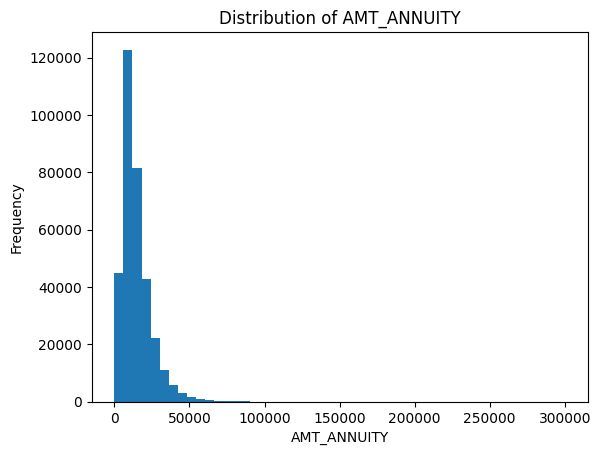

In [ ]:
amt_annuity_values = previous["AMT_ANNUITY"].dropna()

plt.hist(amt_annuity_values, bins=50)
plt.title("Distribution of AMT_ANNUITY")
plt.xlabel("AMT_ANNUITY")
plt.ylabel("Frequency")
plt.show()


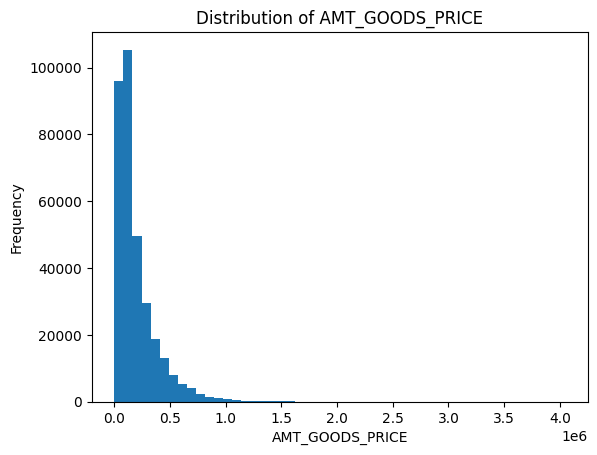

In [ ]:
amt_goods_values = previous["AMT_GOODS_PRICE"].dropna()

plt.hist(amt_goods_values, bins=50)
plt.title("Distribution of AMT_GOODS_PRICE")
plt.xlabel("AMT_GOODS_PRICE")
plt.ylabel("Frequency")
plt.show()

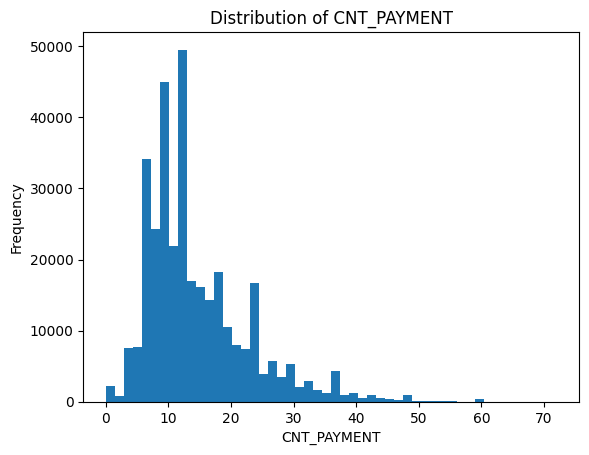

In [ ]:
cnt_payment_values = previous["CNT_PAYMENT"].dropna()

plt.hist(cnt_payment_values, bins=50)
plt.title("Distribution of CNT_PAYMENT")
plt.xlabel("CNT_PAYMENT")
plt.ylabel("Frequency")
plt.show()

=> Ta thấy rằng các biến này phân phối không đều, cụ thể là bị lệch trái nên phương án có thể tối ưu ở đây là thay thế các giá trị thiếu là median để cấu trúc dữ liệu ít bị thay đổi

In [ ]:
# Tính trung vị và thay thế NaN cho AMT_ANNUITY
median_amt_annuity = previous["AMT_ANNUITY"].median()
previous["AMT_ANNUITY"] = previous["AMT_ANNUITY"].fillna(median_amt_annuity)

# Tính trung vị và thay thế NaN cho AMT_GOODS_PRICE
median_amt_goods_price = previous["AMT_GOODS_PRICE"].median()
previous["AMT_GOODS_PRICE"] = previous["AMT_GOODS_PRICE"].fillna(median_amt_goods_price)

# Tính trung vị và thay thế NaN cho CNT_PAYMENT
median_cnt_payment = previous["CNT_PAYMENT"].median()
previous["CNT_PAYMENT"] = previous["CNT_PAYMENT"].fillna(median_cnt_payment)

# Hiển thị kết quả
missing_values_table(previous).head(20)


Your selected dataframe has 15 columns.
There are 0 columns that have missing values.


,Missing Values,% of Total Values


In [ ]:
missing_values_table(data_clean)
missing_values_table(berau_full)
missing_values_table(previous)

Your selected dataframe has 35 columns.
There are 0 columns that have missing values.
Your selected dataframe has 46 columns.
There are 0 columns that have missing values.
Your selected dataframe has 15 columns.
There are 0 columns that have missing values.


,Missing Values,% of Total Values


In [ ]:
data_clean

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,0.0,1,0,1,0,Laborers,1.0,2,2,Business Entity Type 3,0.083037,0.262949,0.139376,-1134.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,0.0,1,0,1,0,Core staff,2.0,1,1,School,0.311267,0.622246,0.535276,-828.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,0,Laborers,1.0,2,2,Government,0.505998,0.555912,0.729567,-815.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,0.0,1,0,0,0,Laborers,2.0,2,2,Business Entity Type 3,0.505998,0.650442,0.535276,-617.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,0.0,1,0,0,0,Core staff,1.0,2,2,Religion,0.505998,0.322738,0.535276,-1106.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,225000.0,Unaccompanied,Working,Secondary / secondary special,Separated,With parents,0.032561,-9327,-236,-8456.0,-1982,0.0,1,0,0,0,Sales staff,1.0,1,1,Services,0.145570,0.681632,0.535276,-273.0
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,225000.0,Unaccompanied,Pensioner,Secondary / secondary special,Widow,House / apartment,0.025164,-20775,365243,-4388.0,-4090,0.0,0,0,1,0,Unknown,1.0,2,2,XNA,0.505998,0.115992,0.535276,0.0
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,585000.0,Unaccompanied,Working,Higher education,Separated,House / apartment,0.005002,-14966,-7921,-6737.0,-5150,0.0,1,0,0,1,Managers,1.0,3,3,School,0.744026,0.535722,0.218859,-1909.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,319500.0,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,0.005313,-11961,-4786,-2562.0,-931,0.0,1,0,0,0,Laborers,2.0,2,2,Business Entity Type 1,0.505998,0.514163,0.661024,-322.0


In [ ]:
# Bước 1: Join Inner với previous (Chỉ giữ lại những khách hàng có lịch sử vay trước đó)
# data_clean là bảng application_train của bạn
combined_df = data_clean.merge(previous, on='SK_ID_CURR', how='inner')

# Bước 2: Join Left với bureau (Giữ lại tất cả từ bảng trên, nếu không có bureau thì để NA)
final_df = combined_df.merge(berau_full, on='SK_ID_CURR', how='left')

print(f"Kích thước sau khi join: {final_df.shape}")

Kích thước sau khi join: (291057, 95)


In [ ]:
final_df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE_x,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT_x,AMT_ANNUITY_x,AMT_GOODS_PRICE_x,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,SK_ID_PREV,NAME_CONTRACT_TYPE_y,AMT_ANNUITY_y,AMT_APPLICATION,AMT_CREDIT_y,AMT_GOODS_PRICE_y,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_GOODS_CATEGORY,NAME_PRODUCT_TYPE,CNT_PAYMENT,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MEDIAN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_DAYS_CREDIT_ENDDATE_MIN,BUREAU_DAYS_CREDIT_ENDDATE_MAX,BUREAU_DAYS_CREDIT_ENDDATE_MEAN,BUREAU_AMT_CREDIT_SUM_SUM,BUREAU_AMT_CREDIT_SUM_MAX,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_AMT_CREDIT_SUM_DEBT_MAX,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM,BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN,BUREAU_AMT_ANNUITY_MEAN,BUREAU_CNT_CREDIT_PROLONG_SUM,BUREAU_CNT_CREDIT_PROLONG_MEAN,BUREAU_CREDIT_ACTIVE_Active,BUREAU_CREDIT_ACTIVE_Bad debt,BUREAU_CREDIT_ACTIVE_Closed,BUREAU_CREDIT_ACTIVE_Sold,BUREAU_CREDIT_TYPE_Another type of loan,BUREAU_CREDIT_TYPE_Car loan,BUREAU_CREDIT_TYPE_Cash loan (non-earmarked),BUREAU_CREDIT_TYPE_Consumer credit,BUREAU_CREDIT_TYPE_Credit card,BUREAU_CREDIT_TYPE_Interbank credit,BUREAU_CREDIT_TYPE_Loan for business development,BUREAU_CREDIT_TYPE_Loan for purchase of shares (margin lending),BUREAU_CREDIT_TYPE_Loan for the purchase of equipment,BUREAU_CREDIT_TYPE_Loan for working capital replenishment,BUREAU_CREDIT_TYPE_Microloan,BUREAU_CREDIT_TYPE_Mobile operator loan,BUREAU_CREDIT_TYPE_Mortgage,BUREAU_CREDIT_TYPE_Real estate loan,BUREAU_CREDIT_TYPE_Unknown type of loan,BUREAU_COUNT,ACTIVE_AMT_CREDIT_SUM_MEAN,ACTIVE_AMT_CREDIT_SUM_MAX,ACTIVE_AMT_CREDIT_SUM_DEBT_MEAN,ACTIVE_AMT_CREDIT_SUM_DEBT_MAX,ACTIVE_DAYS_CREDIT_MEAN,ACTIVE_DAYS_CREDIT_MAX
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,0.0,1,0,1,0,Laborers,1.0,2,2,Business Entity Type 3,0.083037,0.262949,0.139376,-1134.0,1038818,Consumer loans,9251.775000,179055.000,179055.00,179055.000,XAP,Approved,-606,XNA,XAP,Vehicles,XNA,24.000000,-1437.0,-103.0,-874.000000,-1042.5,0.0,0.0,-1072.0,780.0,-349.000000,865055.565,450000.0,108131.945625,245781.00,245781.0,49156.20000,0.0,0.0,0.0,0.0,0.000000,2.0,0.0,6.0,0.0,0.0,0.0,0.0,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,2.409943e+05,450000.0,122890.500,245781.0,-572.5,-103.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,0.0,1,0,1,0,Core staff,2.0,1,1,School,0.311267,0.622246,0.535276,-828.0,1810518,Cash loans,56553.990000,435436.500,484191.00,435436.500,XNA,Approved,-2341,XNA,XAP,XNA,x-sell,10.000000,-2586.0,-606.0,-1400.750000,-1205.5,0.0,0.0,-2434.0,1216.0,-544.500000,1017400.500,810000.0,254350.125000,0.00,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,3.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,8.100000e+05,810000.0,0.000,0.0,-606.0,-606.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,0,Laborers,1.0,2,2,Government,0.505998,0.555912,0.729567,-815.0,1564014,Consumer loans,5357.250000,24282.000,20106.00,24282.000,XAP,Approved,-815,Cash through the bank,XAP,Mobile,XNA,4.000000,-1326.0,-408.0,-

In [ ]:
final_df.to_csv("/content/drive/MyDrive/home-credit-default-risk/data_ch_onehot.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import LabelEncoder

# Đọc dữ liệu đã join của bạn
df = final_df.copy()

# --- BƯỚC 1: XÁC ĐỊNH CÁC CỘT PHÂN LOẠI (CATEGORICAL) ---
# Tự động lấy các cột có kiểu dữ liệu là Object (chữ)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Loại bỏ các cột không cần thiết nếu có (ví dụ ID hoặc Target)
cols_to_exclude = ['SK_ID_CURR', 'TARGET']
cat_cols = [c for c in cat_cols if c not in cols_to_exclude]

# --- BƯỚC 2: LABEL ENCODING & LƯU TRỮ ---
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # Fillna bằng 'Unknown' để tránh lỗi khi gặp giá trị trống
    df[col] = df[col].astype(str).fillna('Unknown')
    # Tạo cột _label
    df[f'{col}_label'] = le.fit_transform(df[col])
    # Lưu encoder vào dict để dùng cho App
    label_encoders[col] = le

# --- BƯỚC 3: ONE-HOT ENCODING ---
# Tạo bản dummy cho toàn bộ các cột categorical
df_final = pd.get_dummies(df, columns=cat_cols)

# --- BƯỚC 4: LƯU CÁC FILE QUAN TRỌNG CHO APP ---

# 1. Lưu danh sách cột chuẩn (Rất quan trọng để reindex trong App)
all_columns = df_final.columns.tolist()
with open("/content/drive/MyDrive/Home_credit_risk_ARTIFACT/train/all_columns.pkl", "wb") as f:
    pickle.dump(all_columns, f)

# 2. Lưu bộ Label Encoders
with open("/content/drive/MyDrive/Home_credit_risk_ARTIFACT/train/label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

# 3. Lưu giá trị Median để App điền vào các cột bị thiếu (Bureau/Previous)
# Chỉ lấy các cột số để tính median
numeric_cols = df_final.select_dtypes(include=[np.number]).columns
impute_values = df_final[numeric_cols].median().to_dict()
with open("/content/drive/MyDrive/Home_credit_risk_ARTIFACT/train/impute_values.pkl", "wb") as f:
    pickle.dump(impute_values, f)

print(f"Xử lý xong! Tổng số cột sau One-hot: {len(all_columns)}")

Xử lý xong! Tổng số cột sau One-hot: 287


In [ ]:
static_data = df_final.copy()

In [ ]:
import pandas as pd
import numpy as np
import pickle

# Giả sử df_final là dataframe 287 cột của bạn
# 1. Tách các cột số để xử lý NaN
numeric_cols = static_data.select_dtypes(include=[np.number]).columns
categorical_cols = static_data.select_dtypes(exclude=[np.number]).columns

# 2. Tạo dictionary lưu giá trị Median (để App dùng sau này)
impute_values = static_data[numeric_cols].median().to_dict()

# 3. Điền khuyết cho tập Train
static_data[numeric_cols] = static_data[numeric_cols].fillna(static_data[numeric_cols].median())
static_data[categorical_cols] = static_data[categorical_cols].fillna('None')

# 4. Kiểm tra lại lần cuối
if static_data.isnull().sum().sum() == 0:
    print("Dữ liệu đã sạch 100% NaN.")

# --- LƯU TRỮ CHO APP ---
with open("/content/drive/MyDrive/Home_credit_risk_ARTIFACT/train/all_columns.pkl", "wb") as f:
    pickle.dump(static_data.columns.tolist(), f)

with open("/content/drive/MyDrive/Home_credit_risk_ARTIFACT/train/impute_values.pkl", "wb") as f:
    pickle.dump(impute_values, f)

✅ Chúc mừng! Dữ liệu đã sạch 100% NaN.


In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Giả sử application_train_temp là DataFrame pandas
# application_train_temp = pd.read_csv("application_train.csv")

# Các cột cần One-Hot Encoding
ohe_columns = [
    'NAME_CONTRACT_TYPE',
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_TYPE_SUITE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE'
]

# Tạo ColumnTransformer để OHE các cột danh mục
preprocessor = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ohe_columns)
    ],
    remainder="passthrough"   # giữ nguyên các cột còn lại
)

# Pipeline tương đương PySpark Pipeline
pipeline_ohe = Pipeline(steps=[
    ("ohe_preprocessing", preprocessor)
])

# Fit & transform
application_encoded = pipeline_ohe.fit_transform(data_clean)

# Chuyển output thành DataFrame pandas
# Lấy tên các cột OHE
ohe_feature_names = pipeline_ohe.named_steps["ohe_preprocessing"] \
                                .named_transformers_["ohe"].get_feature_names_out(ohe_columns)

# Lấy tên các cột không bị encode
other_columns = [c for c in data_clean.columns if c not in ohe_columns]

# Tạo DataFrame cuối cùng
data_final = pd.DataFrame(application_encoded,
                                 columns=list(ohe_feature_names) + other_columns)



In [ ]:
data_final.head(10)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Các cột cần Label Encoding
label_columns = [
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'OCCUPATION_TYPE',
    'ORGANIZATION_TYPE'
]

# Tạo ColumnTransformer cho Label Encoding
preprocessor_label = ColumnTransformer(
    transformers=[
        ("label_enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), label_columns)
    ],
    remainder="passthrough"
)

# Tạo Pipeline giống PySpark
pipeline_label = Pipeline(steps=[
    ("label_encoding", preprocessor_label)
])

# Fit & transform
application_encoded = pipeline_label.fit_transform(data_final)

# Chuyển kết quả thành DataFrame
# Lấy tên cột output
label_feature_names = [col + "_index" for col in label_columns]
other_columns = [c for c in data_final.columns if c not in label_columns]

data_final = pd.DataFrame(
    application_encoded,
    columns=label_feature_names + other_columns
)


In [ ]:
data_final

In [ ]:
previous_final = previuos_final.drop('TARGET', axis = 1)

In [ ]:
previuos_final

In [ ]:
overlap_cols = [col for col in previuos_final.columns if col in data_final.columns and col != 'SK_ID_CURR']
previous_final = previous_final.drop(columns=overlap_cols, errors='ignore')
previous_final = previous_final[[c for c in previous_final.columns if c != 'SK_ID_CURR']]\
    .join(previous_final[['SK_ID_CURR']])



In [ ]:
appli_pre = data_final.merge(previous_final, on='SK_ID_CURR', how='inner')

appli_pre.head(10)

In [ ]:
# Join với bảng application + previous
static_data_test = appli_pre.merge(
    berau_full,
    on="SK_ID_CURR",
    how="left"     # rất quan trọng để không mất khách hàng
)


In [ ]:
static_data_test

In [ ]:
missing_values_table(static_data)

Your selected dataframe has 287 columns.
There are 46 columns that have missing values.


,Missing Values,% of Total Values
BUREAU_DAYS_CREDIT_MIN,41550,14.3
BUREAU_DAYS_CREDIT_MAX,41550,14.3
BUREAU_DAYS_CREDIT_MEAN,41550,14.3
BUREAU_DAYS_CREDIT_MEDIAN,41550,14.3
BUREAU_CREDIT_DAY_OVERDUE_MAX,41550,14.3
BUREAU_CREDIT_DAY_OVERDUE_MEAN,41550,14.3
BUREAU_DAYS_CREDIT_ENDDATE_MIN,41550,14.3
BUREAU_DAYS_CREDIT_ENDDATE_MAX,41550,14.3
BUREAU_DAYS_CREDIT_ENDDATE_MEAN,41550,14.3
BUREAU_AMT_CREDIT_SUM_SUM,41550,14.3


In [ ]:
df_filtered = berau_full[berau_full.index == 100006]

print("--- Các hàng có SK_ID_CURR là 100006 ---")
print(df_filtered)

--- Các hàng có SK_ID_CURR là 100006 ---
Empty DataFrame
Columns: [BUREAU_DAYS_CREDIT_MIN, BUREAU_DAYS_CREDIT_MAX, BUREAU_DAYS_CREDIT_MEAN, BUREAU_DAYS_CREDIT_MEDIAN, BUREAU_CREDIT_DAY_OVERDUE_MAX, BUREAU_CREDIT_DAY_OVERDUE_MEAN, BUREAU_DAYS_CREDIT_ENDDATE_MIN, BUREAU_DAYS_CREDIT_ENDDATE_MAX, BUREAU_DAYS_CREDIT_ENDDATE_MEAN, BUREAU_AMT_CREDIT_SUM_SUM, BUREAU_AMT_CREDIT_SUM_MAX, BUREAU_AMT_CREDIT_SUM_MEAN, BUREAU_AMT_CREDIT_SUM_DEBT_SUM, BUREAU_AMT_CREDIT_SUM_DEBT_MAX, BUREAU_AMT_CREDIT_SUM_DEBT_MEAN, BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM, BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN, BUREAU_AMT_ANNUITY_MEAN, BUREAU_CNT_CREDIT_PROLONG_SUM, BUREAU_CNT_CREDIT_PROLONG_MEAN, BUREAU_CREDIT_ACTIVE_Active, BUREAU_CREDIT_ACTIVE_Bad debt, BUREAU_CREDIT_ACTIVE_Closed, BUREAU_CREDIT_ACTIVE_Sold, BUREAU_CREDIT_TYPE_Another type of loan, BUREAU_CREDIT_TYPE_Car loan, BUREAU_CREDIT_TYPE_Cash loan (non-earmarked), BUREAU_CREDIT_TYPE_Consumer credit, BUREAU_CREDIT_TYPE_Credit card, BUREAU_CREDIT_TYPE_Interbank credit

In [ ]:
berau_full = berau_full.reset_index()

In [ ]:
# 1. Tạo biến cờ HAS_BUREAU
static_data['HAS_BUREAU'] = np.where(static_data['SK_ID_CURR'].isin(berau_full['SK_ID_CURR']), 1, 0)

# 2. Xác định nhóm feature theo logic
count_features = [col for col in static_data.columns if 'COUNT' in col or 'SUM' in col]
binary_features = [col for col in static_data.columns if 'FLAG' in col or 'ANY' in col]
stat_features = [
    col for col in static_data.columns
    if any(x in col for x in ['MEAN', 'MAX', 'MIN', 'MEDIAN', 'STD'])
]

# Loại bỏ các cột không phải aggregate
exclude = ['SK_ID_CURR', 'HAS_BUREAU']
count_features = [c for c in count_features if c not in exclude]
binary_features = [c for c in binary_features if c not in exclude]
stat_features = [c for c in stat_features if c not in exclude]

# 3. Fill giá trị
static_data[count_features] = static_data[count_features].fillna(0)
static_data[binary_features] = static_data[binary_features].fillna(0)
static_data[stat_features] = static_data[stat_features].fillna(-1)

# Đối với các cột khác (nếu có), fill bằng -1 cho consistency
other_cols = static_data.columns.difference(
    ['SK_ID_CURR'] + count_features + binary_features + stat_features + ['HAS_BUREAU']
)
static_data[other_cols] = static_data[other_cols].fillna(-1)

print("Hoàn tất xử lý dữ liệu.")
static_data

KeyError: 'SK_ID_CURR'

In [ ]:
import pickle

# Giả sử 'df' là DataFrame tổng cuối cùng đã qua xử lý dummies
all_columns = df.columns.tolist()

# Lưu file này để App Streamlit biết cách "ép" dữ liệu thô về đúng định dạng dummy
with open('/content/drive/MyDrive/Home_credit_risk_ARTIFACT/train/categories_columns.pkl', 'wb') as f:
    pickle.dump(all_columns, f)

print("Đã lưu bộ khung dummy chuẩn!")

In [ ]:
import pickle

# 1. Lưu danh sách cột chuẩn sau khi đã Join và One-hot
all_columns = data_clean.columns.tolist() # data_clean là bảng cuối cùng sau khi join
with open("all_columns.pkl", "wb") as f:
    pickle.dump(all_columns, f)

# 2. Lưu các giá trị Median để điền missing value cho khách hàng mới
# Ví dụ: median_amt_annuity = data["AMT_ANNUITY"].median()
impute_values = {
    'AMT_ANNUITY': data["AMT_ANNUITY"].median(),
    'AMT_GOODS_PRICE': data["AMT_GOODS_PRICE"].median(),
    'EXT_SOURCE_1': 0.5, # Hoặc giá trị trung bình bạn dùng
    'EXT_SOURCE_2': 0.5,
    'EXT_SOURCE_3': 0.5
}
with open("impute_values.pkl", "wb") as f:
    pickle.dump(impute_values, f)

# 3. Lưu Scaler (Nếu bạn có dùng StandardScaler)
# with open("scaler.pkl", "wb") as f:
#     pickle.dump(scaler, f)

In [ ]:
import pickle
from sklearn.preprocessing import LabelEncoder

# Danh sách các cột cần mã hóa theo dạng index
cat_cols = ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    # "Học" từ dữ liệu gốc
    data[f'{col}_index'] = le.fit_transform(data[col].astype(str))
    # Lưu đối tượng encoder vào dictionary
    encoders[col] = le

# LƯU TẤT CẢ ENCODERS VÀO MỘT FILE DUY NHẤT
with open("label_encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

In [ ]:
static_data_test.to_csv("/content/drive/MyDrive/Home_credit_risk_ARTIFACT/train/static_data_test.csv", index=False)

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/static_data.csv")
data

In [ ]:
data.columns.values